In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load dataset
data = pd.read_csv("/content/Alphabets_data.csv")

# Explore the data
print(data.info())
print(data.describe())

# Separate features and target
X = data.drop(columns=["letter"])  # Features
y = data["letter"]                 # Labels

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB
None
               xbox          ybox         width       height         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.00000

# Model Implementation

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the ANN model
def create_ann_model():
    model = Sequential([
        Dense(64, input_dim=X_train.shape[1], activation="relu"),
        Dense(32, activation="relu"),
        Dense(len(label_encoder.classes_), activation="softmax")  # Output layer
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Build and train the model
model = create_ann_model()
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1493 - loss: 3.0746 - val_accuracy: 0.4175 - val_loss: 2.1173
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4931 - loss: 1.8836 - val_accuracy: 0.5878 - val_loss: 1.5592
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5848 - loss: 1.4959 - val_accuracy: 0.6056 - val_loss: 1.3963
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6386 - loss: 1.3085 - val_accuracy: 0.6416 - val_loss: 1.2943
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6596 - loss: 1.2210 - val_accuracy: 0.6753 - val_loss: 1.2029
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6735 - loss: 1.1615 - val_accuracy: 0.6719 - val_loss: 1.1781
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6939 - loss: 1.0980 - val_accuracy: 0.6991 - val_loss: 1.1090
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7090 - loss: 1.0643 - val_accuracy: 0.

#Hyperparameter tuing

In [13]:
pip install keras-tuner


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras_tuner import RandomSearch

# Define a model-building function for hyperparameter tuning
def build_model(hp):
    model = Sequential()
    # Add input layer and first hidden layer with tunable units
    model.add(Dense(hp.Int("units_1", min_value=32, max_value=128, step=32),
                    activation=hp.Choice("activation_1", ["relu", "tanh"]),
                    input_dim=X_train.shape[1]))
    # Add second hidden layer with tunable units
    model.add(Dense(hp.Int("units_2", min_value=32, max_value=128, step=32),
                    activation=hp.Choice("activation_2", ["relu", "tanh"])))
    # Add output layer
    model.add(Dense(len(label_encoder.classes_), activation="softmax"))

    # Compile the model with tunable optimizer and learning rate
    model.compile(
        optimizer=hp.Choice("optimizer", ["adam", "sgd"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Initialize the tuner
tuner = RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=1,  # Number of times to train each combination
    directory="hyperparameter_tuning",  # Directory to save results
    project_name="ann_tuning"
)

# Perform the hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Number of Units in Layer 1: {best_hps.get('units_1')}")
print(f"Best Number of Units in Layer 2: {best_hps.get('units_2')}")
print(f"Best Activation in Layer 1: {best_hps.get('activation_1')}")
print(f"Best Activation in Layer 2: {best_hps.get('activation_2')}")
print(f"Best Optimizer: {best_hps.get('optimizer')}")

# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the best model on the test data
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy of Best Model: {test_accuracy}")


Trial 10 Complete [00h 00m 16s]
val_accuracy: 0.8293750286102295

Best val_accuracy So Far: 0.8293750286102295
Total elapsed time: 00h 02m 51s
Best Number of Units in Layer 1: 128
Best Number of Units in Layer 2: 96
Best Activation in Layer 1: tanh
Best Activation in Layer 2: tanh
Best Optimizer: adam
Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2821 - loss: 2.6660 - val_accuracy: 0.6147 - val_loss: 1.4462
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6510 - loss: 1.2907 - val_accuracy: 0.6966 - val_loss: 1.1312
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7109 - loss: 1.0624 - val_accuracy: 0.7328 - val_loss: 1.0206
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7379 - loss: 0.9624 - val_accuracy: 0.7547 - val_loss: 0.9202
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7578 - loss: 0.8738 - val_accuracy: 0.7691 - val_loss: 0.8617
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

#Evaluation

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Default Model Performance:
              precision    recall  f1-score   support

           A       0.89      0.90      0.89       149
           B       0.63      0.85      0.73       153
           C       0.80      0.69      0.74       137
           D       0.71      0.83      0.76       156
           E       0.77      0.80      0.79       141
           F       0.83      0.70      0.76       140
           G       0.68      0.63      0.66       160
           H       0.70      0.52      0.60       144
           I       0.92      0.80      0.86       146
           J       0.85      0.85      0.85       149
           K       0.68      0.74      0.71       130
           L       0.89      0.80      0.84       155
           M       0.89      0.91      0.90       168
           N       0.82      0.81      0.82       151
           O       0.75      0.77      0.76       145
           P       0.89      0.80      0.84       173
           Q 

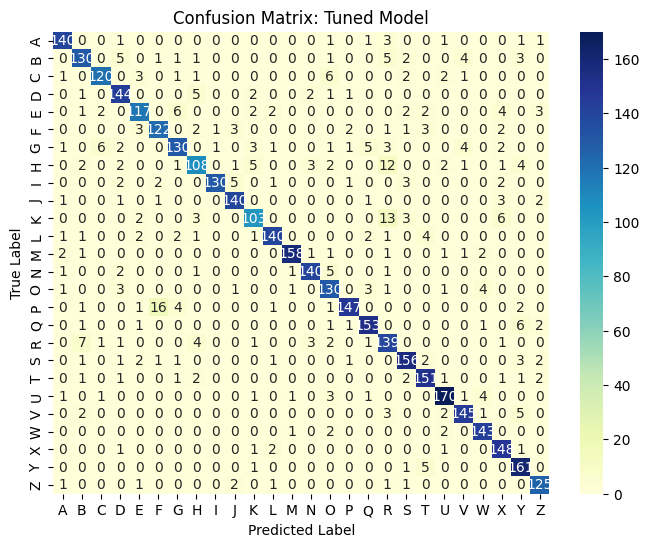

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Predict on test set for default and tuned models
y_pred_default = model.predict(X_test)  # For default model - Remove argmax(axis=1)
y_pred_tuned = best_model.predict(X_test).argmax(axis=1)  # For tuned model

# Classification Report for Default Model
print("Default Model Performance:")
print(classification_report(y_test, y_pred_default, target_names=label_encoder.classes_))

# Classification Report for Tuned Model
print("Tuned Model Performance:")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# Confusion Matrix for Tuned Model
conf_matrix = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix: Tuned Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
